In [6]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [14]:
class Sentiment_schema(BaseModel):
    sentiment: Literal['positive','negative'] = Field(description="The sentiment of the review, either positive or negative")

In [27]:
class DiagnosisSchema(BaseModel):
    issue_type:Literal["UX","performance","bug","Support","Other"] = Field(description="The category of issue mentioned in the review")
    tone:Literal["angry","frustrated","disappointed","calm"] = Field(description="The emotional tone express by the user")
    urgency:Literal["low","medium","high"] = Field(description="How urgent or critical the issue appears to be ")

In [15]:
model=ChatOpenAI(model="gpt-4o-mini")

In [28]:
structured_model=model.with_structured_output(Sentiment_schema)
structured_model2=model.with_structured_output(DiagnosisSchema)

In [17]:
prompt='what is the sentiment of the following review -The software is too bad to use, it keeps crashing and the interface is not user friendly at all'
structured_model.invoke(prompt).sentiment

/home/motherson/Documents/Langgraph-demo/.venv/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sentiment_schema(sentiment='negative'), input_type=Sentiment_schema])
  return self.__pydantic_serializer__.to_python(


'negative'

In [21]:
#first we create states for our graph, these are the different steps in our workflow
class Review_state(TypedDict):
    review: str
    sentiment: Literal['positive','negative']

    diagnosis: dict
    response:str
    

In [42]:
def find_sentiment(state:Review_state)->Review_state:
    response = structured_model.invoke(f"Classify the following review as positive or negative: {state['review']}")
    
    return {'sentiment':response.sentiment}
def check_sentiment(state:Review_state)->Literal['positive_response','run_diagnosis']:
    # response= "positive_response" if state['sentiment']=='positive' else "run_diagnosis"
    return "positive_response" if state['sentiment']=='positive' else "run_diagnosis"
def positive_response(state:Review_state)->Review_state:
    prompt=f'''Diagnose this negative review:\n\n{state['review']}\n""Return issue_type,tone,urgency.'''
    return {'response': model.invoke(prompt).content}

def run_diagnosis(state:Review_state)->Review_state:
    prompt=f"""Diagnose this negative review:\n\n{state['review']}\n"
    "return issue_type,tone,urgency.
    """
    response=structured_model2.invoke(prompt)
    return {'diagnosis':response.model_dump()}
def negative_response(state:Review_state):
    diagnosis=state['diagnosis']
    prompt=f"""You are a support assistant.The user had a '{diagnosis['issue_type']}' issue,sounded '{diagnosis['tone']}' , and marked urgency as '{diagnosis['urgency']}'. write an empathetic ,helpful resolution message"""
    response=model.invoke(prompt)
    return {'response':response.content}


In [43]:
graph=StateGraph(Review_state)
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("run_diagnosis",run_diagnosis)
graph.add_node("positive_response",positive_response)
graph.add_node("negative_response",negative_response)

#connect edges

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment",check_sentiment)
graph.add_edge("run_diagnosis","negative_response")
graph.add_edge("positive_response",END)
graph.add_edge("negative_response",END)
workflow=graph.compile()

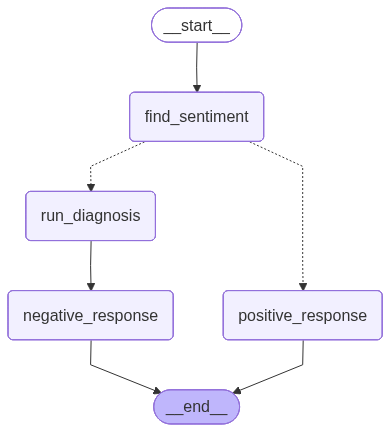

In [44]:
workflow

In [47]:
initial_state={'review': "Terrible experience. Customer support didn’t respond and the issue is still unresolved."}
response=workflow.invoke(initial_state)
print(response)

/home/motherson/Documents/Langgraph-demo/.venv/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sentiment_schema(sentiment='negative'), input_type=Sentiment_schema])
  return self.__pydantic_serializer__.to_python(
/home/motherson/Documents/Langgraph-demo/.venv/lib/python3.11/site-packages/pydantic/main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DiagnosisSchema(issue_typ...trated', urgency='high'), input_type=DiagnosisSchema])
  return self.__pydantic_serializer__.to_python(


{'review': 'Terrible experience. Customer support didn’t respond and the issue is still unresolved.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Support', 'tone': 'frustrated', 'urgency': 'high'}, 'response': "Subject: I'm Here to Help You Resolve Your Issue\n\nDear [User's Name],\n\nI truly understand how frustrating it can be to encounter issues, and I want to assure you that I'm here to help you resolve this as quickly as possible. Your concerns are important to us, and we appreciate your urgency regarding this matter.\n\nCould you please provide me with more details about the specific issue you're facing? Any additional information you share will help me assist you more efficiently. \n\nThank you for your patience, and I look forward to your response so we can get this sorted out for you.\n\nWarm regards,\n\n[Your Name]  \n[Your Position]  \n[Your Contact Information]  \n[Company Name]"}
